In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# images sit in question/a1images/
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# build a Gaussian kernel from scratch using the 2D Gaussian formula
# dividing by K.sum() normalizes it so pixel brightness stays the same after filtering
def gaussian_kernel(size, sigma):
    half = size // 2
    ax   = np.arange(-half, half + 1, dtype=np.float64)
    X, Y = np.meshgrid(ax, ax)
    K    = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return K / K.sum()

In [3]:
# print the 5x5 kernel just to check the values look right
# centre value should be the largest, falling off symmetrically outward
K5 = gaussian_kernel(5, 2)
print('5x5 Gaussian kernel (σ=2):')
print(np.round(K5, 4))

5x5 Gaussian kernel (σ=2):
[[0.0232 0.0338 0.0383 0.0338 0.0232]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0383 0.0558 0.0632 0.0558 0.0383]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0232 0.0338 0.0383 0.0338 0.0232]]


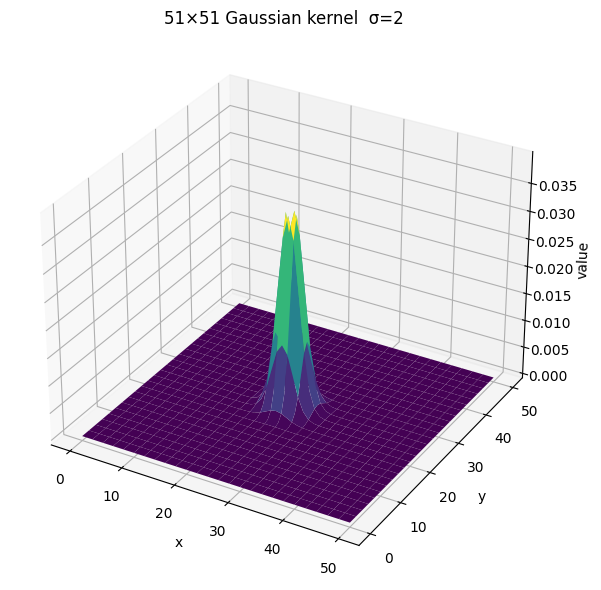

In [4]:
# 3D surface of a 51x51 kernel so the bell-curve shape is obvious
K51  = gaussian_kernel(51, 2)
x    = np.arange(51)
X, Y = np.meshgrid(x, x)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, K51, cmap='viridis', linewidth=0)
ax.set_title('51×51 Gaussian kernel  σ=2')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('value')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q5_gaussian_surface.png'), dpi=150)
plt.show()

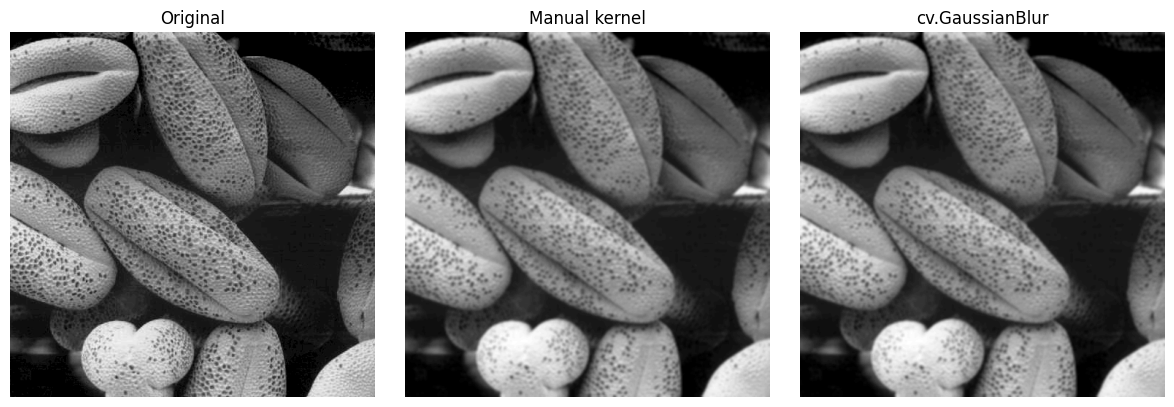

In [5]:
# filter shells.tif with our kernel vs cv2 built-in — should look the same
# filter2D does the convolution manually; GaussianBlur is cv2s optimized version
img     = cv2.imread(os.path.join(IMG_DIR, 'shells.tif'), cv2.IMREAD_GRAYSCALE)
manual  = cv2.filter2D(img, -1, K5.astype(np.float32))
builtin = cv2.GaussianBlur(img, (5, 5), 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes,
                     [img, manual, builtin],
                     ['Original', 'Manual kernel', 'cv.GaussianBlur']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q5_smoothing.png'), dpi=150)
plt.show()